<a href="https://colab.research.google.com/github/mmeenakshibio2016-byte/-Drug-Response-Prediction-ML-model-to-predict-cancer-cell-line-response-to-drugs-TDC-dataset-./blob/main/Customerchurn_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
github =("https://github.com/IBM/telco-customer-churn-on-icp4d")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
url ="https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [4]:
pd.set_option('display.max_columns',None)

In [5]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df['gender'].value_counts()

,count
gender,
Male,3555
Female,3488


In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')
df['gender'] = df['gender'].map({"Female":0,"Male":1})
df['Churn']  =df['Churn'].map({"No":10,"Yes":1})

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   int64  
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [11]:
import pandas as pd
# Create a temporary DataFrame to get the factorization mapping for 'PaymentMethod'
temp_url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
temp_original_df = pd.read_csv(temp_url)
factorized_payment_method, unique_payment_methods = pd.factorize(temp_original_df['PaymentMethod'])
mailed_check_value = -1
for i, method in enumerate(unique_payment_methods):
    if method == 'Mailed check':
        mailed_check_value = i
        break
print(f"The factorized value for 'Mailed check' is: {mailed_check_value}")

The factorized value for 'Mailed check' is: 1


In [12]:
male_customers = df[df['gender'] == 1].shape[0]
print(f"Total number of male customers: {male_customers}")

Total number of male customers: 3555


In [13]:
dsl_customers = df[df['InternetService'] == 'DSL'].shape[0]
print(f"Total number of customers with DSL Internet Service: {dsl_customers}")

Total number of customers with DSL Internet Service: 2421


In [14]:
new_customer = df[(df['tenure'] < 10) | (df['TotalCharges'] < 500)]
print("Customers with tenure less than 10 months or TotalCharges less than $500:")
new_customer.head()

Customers with tenure less than 10 months or TotalCharges less than $500:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,10
2,3668-QPYBK,1,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
4,9237-HQITU,0,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
5,9305-CDSKC,0,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
7,6713-OKOMC,0,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,10


In [15]:
import pandas as pd

# Load the DataFrame if it's not already defined
if 'df' not in locals() and 'df' not in globals():
    url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
    df = pd.read_csv(url)

    # Apply the same preprocessing steps as in previous cells
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['gender'] = df['gender'].map({"Female": 0, "Male": 1})
    df['Churn'] = df['Churn'].map({"No": 10, "Yes": 1})
    df.dropna(inplace=True)

    # Factorize relevant object columns used in the filter, mirroring K7S4Xdr7vcAO
    # Only factorizing 'PaymentMethod' here as it's directly used in this cell.
    # Other factorizations from K7S4Xdr7vcAO would typically also apply if running the full notebook.
    # For 'PaymentMethod', we need to ensure consistent mapping with `mailed_check_value`.
    # Since mailed_check_value was derived from factorizing the original data, we'll factorize df's PaymentMethod here.
    original_payment_methods = pd.read_csv(url)['PaymentMethod'].unique()
    payment_method_mapping = {method: i for i, method in enumerate(original_payment_methods)}
    df['PaymentMethod'] = df['PaymentMethod'].map(payment_method_mapping)


# Assuming mailed_check_value is defined from previous execution (cell 26cf7dfd)
# If it's not, you'd need to define it here or ensure cell 26cf7dfd runs first.
# mailed_check_value = 1 # Based on the output of cell 26cf7dfd

new_customer = df[(df['gender'] == 0) & (df['SeniorCitizen'] == 1) & (df['PaymentMethod'] == mailed_check_value)]
print("Female senior citizens with 'Mailed check' payment method:")
new_customer.head()

Female senior citizens with 'Mailed check' payment method:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


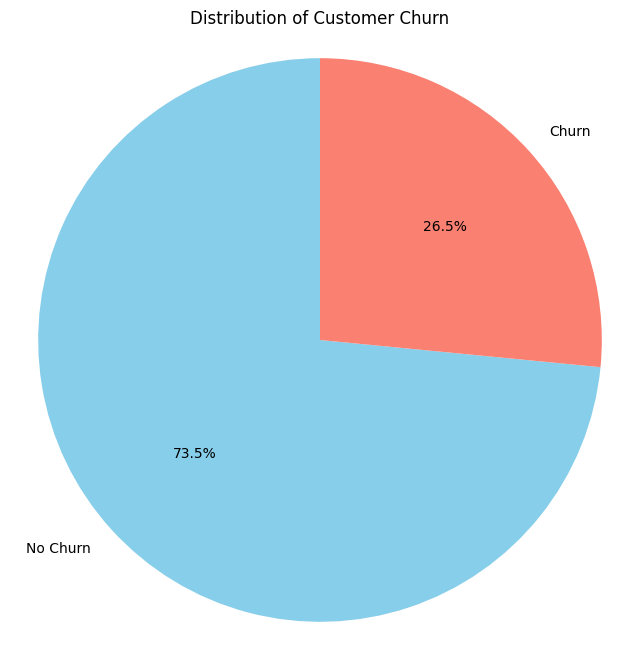

In [16]:
import matplotlib.pyplot as plt

churn_counts = df['Churn'].value_counts()

# Map the numeric churn values back to meaningful labels for the pie chart
churn_labels = {10: 'No Churn', 1: 'Churn'}
labels = [churn_labels[val] for val in churn_counts.index]

plt.figure(figsize=(8, 8))
plt.pie(churn_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'salmon'])
plt.title('Distribution of Customer Churn')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

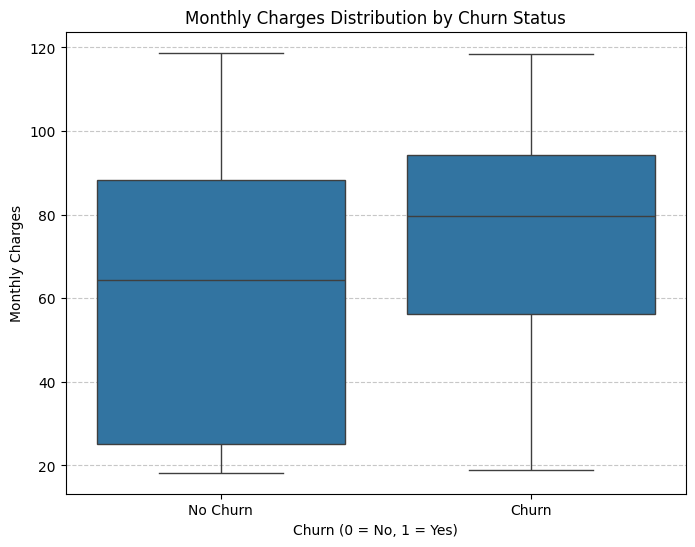

In [17]:
df['Churn'] = df['Churn'].replace({10: 0, 1: 1})
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges Distribution by Churn Status')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Monthly Charges')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [18]:
#Model building
# We are starting off by extracting the target and feature columns.
x = df[['tenure']]
y = df[['Churn']]
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.30,random_state=42)

In [19]:
from keras.models import Sequential
from keras.layers import Dense
model = Sequential()
model.add(Dense(12, input_dim=1, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model. compile(loss = model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy']))
model.fit(x_train, y_train, epochs=150,validation_data=(x_test,y_test))

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7515 - loss: 0.5836 - val_accuracy: 0.7425 - val_loss: 0.5590
Epoch 2/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7544 - loss: 0.5144 - val_accuracy: 0.7553 - val_loss: 0.5129
Epoch 3/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7475 - loss: 0.5137 - val_accuracy: 0.7283 - val_loss: 0.5173
Epoch 4/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7440 - loss: 0.5136 - val_accuracy: 0.7283 - val_loss: 0.5134
Epoch 5/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7414 - loss: 0.5123 - val_accuracy: 0.7283 - val_loss: 0.5190
Epoch 6/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7379 - loss: 0.5135 - val_accuracy: 0.7283 - val_loss: 0.5099
Epoch 7/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7406 - loss: 0.5136 - val_accuracy: 0.7283 - val_loss: 0.5110
Epoch 8/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7465 - loss: 0.5129 - val_accuracy: 0.7283

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


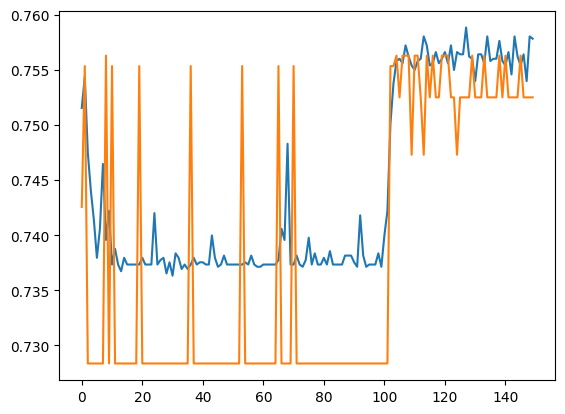

In [20]:
import numpy as np
np.mean(model.history.history['val_accuracy'])
y_pred=(model.predict(x_test) > 0.5).astype("int32")
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)
from matplotlib import pyplot as plt
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.show()

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6430 - loss: 1.9008 - val_accuracy: 0.7553 - val_loss: 0.7376
Epoch 2/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6544 - loss: 1.0861 - val_accuracy: 0.7283 - val_loss: 0.6024
Epoch 3/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6726 - loss: 0.7373 - val_accuracy: 0.7283 - val_loss: 0.5223
Epoch 4/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6824 - loss: 0.6301 - val_accuracy: 0.7283 - val_loss: 0.5139
Epoch 5/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6929 - loss: 0.5763 - val_accuracy: 0.7283 - val_loss: 0.5213
Epoch 6/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7126 - loss: 0.5517 - val_accuracy: 0.7283 - val_loss: 0.5209
Epoch 7/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7229 - loss: 0.5366 - val_accuracy: 0.7283 - val_loss: 0.5183
Epoch 8/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7306 - loss: 0.5368 - val_accuracy: 0.7283

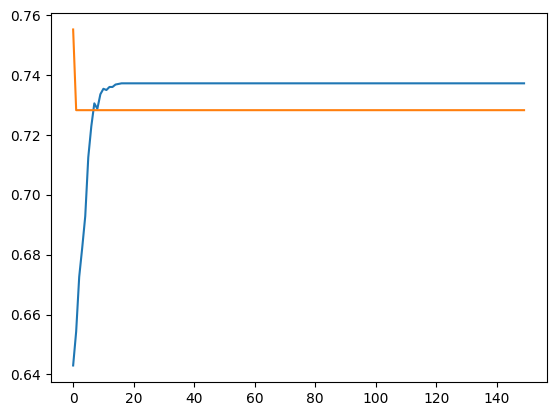

In [21]:
from keras.layers import Dropout
model = Sequential()
model.add(Dense(12,input_dim=1,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(8,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=150,validation_data=(x_test,y_test))
# Corrected prediction method: use model.predict() and threshold
y_pred = (model.predict(x_test) > 0.5).astype("int32")
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

from matplotlib import pyplot as plt
# Corrected keys for plotting accuracy
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.show()

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7373 - loss: nan - val_accuracy: 0.7283 - val_loss: nan
Epoch 2/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7373 - loss: nan - val_accuracy: 0.7283 - val_loss: nan
Epoch 3/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7373 - loss: nan - val_accuracy: 0.7283 - val_loss: nan
Epoch 4/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7373 - loss: nan - val_accuracy: 0.7283 - val_loss: nan
Epoch 5/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7373 - loss: nan - val_accuracy: 0.7283 - val_loss: nan
Epoch 6/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7373 - loss: nan - val_accuracy: 0.7283 - val_loss: nan
Epoch 7/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7373 - loss: nan - val_accuracy: 0.7283 - val_loss: nan
Epoch 8/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7373 - loss: nan - val_accuracy: 0.7283 - val_loss: nan
Epoch 9/150
155/155 ━━━━━━━━

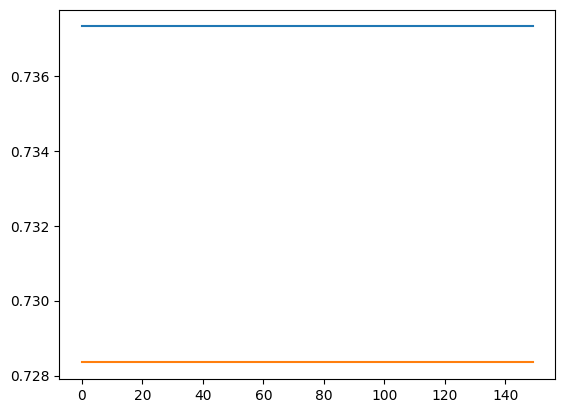

In [22]:
x = df[['MonthlyCharges','tenure', 'TotalCharges']]
y = df[['Churn']]
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.30,random_state=42)
from keras.models import Sequential
from keras.layers import Dense
model = Sequential()
model.add(Dense(12,input_dim=3,activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(x_train,y_train,epochs=150,validation_data=(x_test,y_test))
# Corrected prediction method: use model.predict() and threshold
y_pred = (model.predict(x_test) > 0.5).astype("int32")
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

from matplotlib import pyplot as plt
# Corrected keys for plotting accuracy
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.show()

In [23]:
import numpy as np
np.mean(model.history.history['val_accuracy'])

np.float64(0.7283483147621155)